## Methodology

### Training and Snapshot Collection

A ResNet-20 (~272k parameters) is trained on 15,000 CIFAR-10 samples using SGD ($\eta=0.1$, $\mu=0.9$, weight decay $10^{-4}$, batch size 128, 12 epochs). After every mini-batch update, both the parameter vector $\theta_t \in \mathbb{R}^{272474}$ and the raw mini-batch gradient $g_t \in \mathbb{R}^{272474}$ (captured before `optimizer.step()`) are stored in float32, yielding two parallel trajectories of $T = 1{,}416$ snapshots.

### PCA of Gradients and Iterates

Principal Component Analysis is applied separately to the matrix of gradient vectors and to the matrix of parameter iterates, both of dimension $T \times D$. The explained variance ratio per component (scree plot) and cumulative variance are compared. For the iterate PCA, the theoretical spectrum of an isotropic random walk predicts variance falling off as $6/(\pi^2 k^2)$ for component $k$ (Antognini & Sohl-Dickstein, 2018); this serves as a null-model reference. No analogous closed-form prediction exists for the gradient PCA, as gradients are not cumulative sums. The analysis is repeated separately for three training phases (early 0–33\%, middle 33–66\%, late 66–100\%) to track how the low-dimensional structure of both spaces evolves during training.



In [1]:
# ============================================================
#  ZELLE 1 – Imports
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, Subset
from scipy import stats

In [2]:
# ============================================================
#  ZELLE 2 – Konfiguration
# ============================================================

TRAIN_SIZE   = 15000
TEST_SIZE    = 5000

LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4
L1_LAMBDA    = 0.0

EPOCHS       = 12
BATCH_SIZE   = 128

# PCA-Komponenten für Plots (1-basiert)
PC_X = 1
PC_Y = 2

# Trainingsphase für Gradientenanalyse (Perzentile)
PHASE_LOW  = 0    # unteres Perzentil  (0 = Anfang)
PHASE_HIGH = 100  # oberes Perzentil   (100 = Ende)

N_COMPONENTS = 20  # für Screeplot

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device:      {DEVICE}')
print(f'LR={LR} | Momentum={MOMENTUM} | WD={WEIGHT_DECAY} | L1={L1_LAMBDA}')
print(f'Epochen={EPOCHS} | Batch={BATCH_SIZE}')
print(f'Gradientenanalyse: Perzentile [{PHASE_LOW}, {PHASE_HIGH}]')

Device:      mps
LR=0.1 | Momentum=0.9 | WD=0.0001 | L1=0.0
Epochen=12 | Batch=128
Gradientenanalyse: Perzentile [0, 100]


In [3]:
# ============================================================
#  ZELLE 3 – ResNet20
# ============================================================

class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(planes)
        self.conv2    = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1  = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn1    = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(16, 16, 3, stride=1)
        self.layer2 = self._make_layer(16, 32, 3, stride=2)
        self.layer3 = self._make_layer(32, 64, 3, stride=2)
        self.linear = nn.Linear(64, num_classes)

    def _make_layer(self, in_planes, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(BasicBlock(in_planes, planes, s))
            in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out); out = self.layer2(out); out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[3])
        return self.linear(out.view(out.size(0), -1))


def get_param_vector(model):
    return torch.cat([p.data.flatten()
                      for p in model.parameters()]).cpu().numpy().astype(np.float32)

def get_grad_vector(model):
    grads = []
    for p in model.parameters():
        grads.append(p.grad.flatten() if p.grad is not None
                     else torch.zeros_like(p.data).flatten())
    return torch.cat(grads).cpu().numpy().astype(np.float32)

D = sum(p.numel() for p in ResNet20().parameters())
print(f'ResNet20 | Parameter D = {D:,}')

ResNet20 | Parameter D = 272,474


In [4]:
# ============================================================
#  ZELLE 4 – Daten
# ============================================================

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform_train)
full_test  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)

train_loader = DataLoader(Subset(full_train, range(TRAIN_SIZE)),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(Subset(full_test, range(TEST_SIZE)),
                          batch_size=256, shuffle=False, num_workers=2)

print(f'Train: {TRAIN_SIZE} | Test: {TEST_SIZE}')

Files already downloaded and verified
Files already downloaded and verified
Train: 15000 | Test: 5000


In [5]:
# ============================================================
#  ZELLE 5 – Training
# ============================================================

model     = ResNet20().to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                             momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

history = {
    'train_acc': [], 'test_acc': [],
    'train_loss': [], 'test_loss': [],
    'grad_norm_per_batch': [],
    'grad_norm_per_epoch': [],
}

iterates         = []
gradients        = []   # jeder Batch-Gradient gespeichert
epoch_boundaries = []
batch_counter    = 0

T_total  = len(train_loader) * EPOCHS
ram_iter = T_total * D * 4 / 1e6
ram_grad = T_total * D * 4 / 1e6
print(f'Batches gesamt: {T_total}')
print(f'RAM Iterates:   {ram_iter:.0f} MB')
print(f'RAM Gradienten: {ram_grad:.0f} MB')
print(f'RAM Total:      {ram_iter+ram_grad:.0f} MB')

for epoch in range(1, EPOCHS + 1):
    epoch_boundaries.append(batch_counter)
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    epoch_grad_norms = []

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        if L1_LAMBDA > 0:
            loss = loss + L1_LAMBDA * sum(p.abs().sum() for p in model.parameters())

        loss.backward()

        gv = get_grad_vector(model)
        gnorm = np.linalg.norm(gv)
        history['grad_norm_per_batch'].append(gnorm)
        epoch_grad_norms.append(gnorm)

        # Gradient speichern VOR dem Step
        gradients.append(gv)

        optimizer.step()

        # Iterate speichern NACH dem Step
        iterates.append(get_param_vector(model))

        batch_counter += 1
        running_loss  += loss.item() * batch_x.size(0)
        correct       += (logits.argmax(1) == batch_y).sum().item()
        total         += batch_y.size(0)

    history['train_acc'].append(correct / total)
    history['train_loss'].append(running_loss / total)
    history['grad_norm_per_epoch'].append(np.mean(epoch_grad_norms))

    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            logits  = model(batch_x)
            loss    = criterion(logits, batch_y)
            running_loss += loss.item() * batch_x.size(0)
            correct      += (logits.argmax(1) == batch_y).sum().item()
            total        += batch_y.size(0)

    history['test_acc'].append(correct / total)
    history['test_loss'].append(running_loss / total)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoche {epoch:3d}/{EPOCHS} | '
              f'Train: {history["train_acc"][-1]:.3f} | '
              f'Test:  {history["test_acc"][-1]:.3f} | '
              f'Grad:  {history["grad_norm_per_epoch"][-1]:.4f}')

iterates         = np.array(iterates,   dtype=np.float32)
gradients        = np.array(gradients,  dtype=np.float32)
epoch_boundaries = np.array(epoch_boundaries)

print(f'\niterates.shape  = {iterates.shape}')
print(f'gradients.shape = {gradients.shape}')

Batches gesamt: 1416
RAM Iterates:   1543 MB
RAM Gradienten: 1543 MB
RAM Total:      3087 MB
Epoche   1/12 | Train: 0.277 | Test:  0.292 | Grad:  1.3644
Epoche   5/12 | Train: 0.561 | Test:  0.547 | Grad:  0.9966
Epoche  10/12 | Train: 0.698 | Test:  0.635 | Grad:  0.9652

iterates.shape  = (1416, 272474)
gradients.shape = (1416, 272474)


In [8]:
# ============================================================
#  ZELLE 8 – Phasenauswahl für Gradientenanalyse
# ============================================================

T_total_actual = len(gradients)
idx_low  = int(PHASE_LOW  / 100 * T_total_actual)
idx_high = int(PHASE_HIGH / 100 * T_total_actual)
idx_high = min(idx_high, T_total_actual)

gradients_phase = gradients[idx_low:idx_high]
iterates_phase  = iterates[idx_low:idx_high]

print(f'Gesamte Trajektorie:    {T_total_actual} Iterates')
print(f'Gewählte Phase:         [{PHASE_LOW}%, {PHASE_HIGH}%]')
print(f'Iterates in Phase:      [{idx_low}, {idx_high}]  →  {idx_high - idx_low} Schritte')
print(f'gradients_phase.shape = {gradients_phase.shape}')

Gesamte Trajektorie:    1416 Iterates
Gewählte Phase:         [0%, 100%]
Iterates in Phase:      [0, 1416]  →  1416 Schritte
gradients_phase.shape = (1416, 272474)


In [9]:
# ============================================================
#  ZELLE 9 – PCA auf Gradienten (gewählte Phase)
# ============================================================

print(f'Berechne PCA auf {gradients_phase.shape[0]} Gradienten (D={gradients_phase.shape[1]})...')

pca_grad = PCA(n_components=N_COMPONENTS)
Z_grad   = pca_grad.fit_transform(gradients_phase)

exp_grad = pca_grad.explained_variance_ratio_ * 100
cum_grad = np.cumsum(exp_grad)

print(f'PC{PC_X}: {exp_grad[PC_X-1]:.2f}%')
print(f'PC{PC_Y}: {exp_grad[PC_Y-1]:.2f}%')
print(f'Kumulativ PC1–{N_COMPONENTS}: {cum_grad[-1]:.2f}%')

# Zum Vergleich: PCA auf Iterates derselben Phase
print(f'\nBerechne PCA auf Iterates (gleiche Phase)...')
pca_iter_phase = PCA(n_components=N_COMPONENTS)
Z_iter_phase   = pca_iter_phase.fit_transform(iterates_phase)
exp_iter_phase = pca_iter_phase.explained_variance_ratio_ * 100

Berechne PCA auf 1416 Gradienten (D=272474)...
PC1: 3.61%
PC2: 3.14%
Kumulativ PC1–20: 34.12%

Berechne PCA auf Iterates (gleiche Phase)...


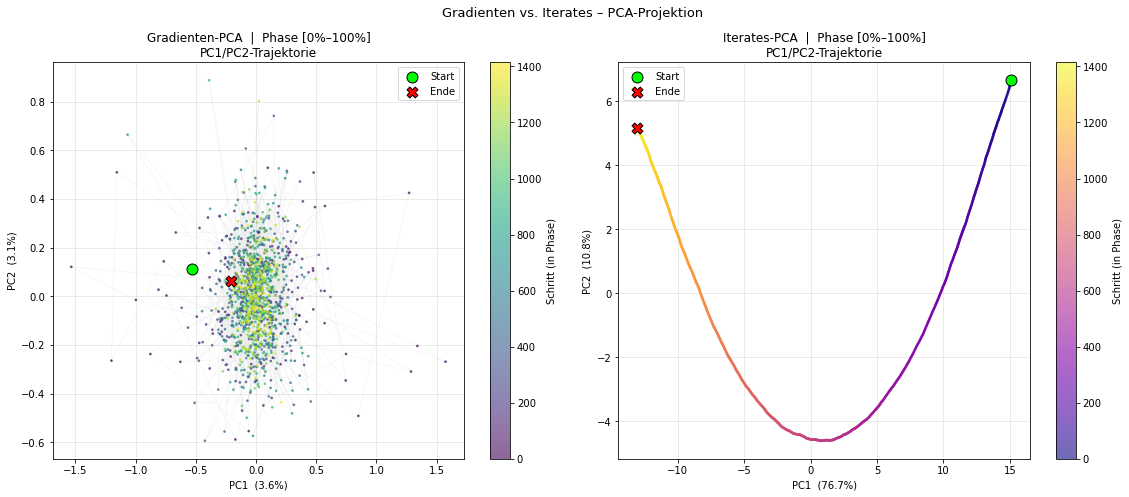

In [10]:
# ============================================================
#  ZELLE 10 – Plot: Trajektorie der Gradienten in PC-Raum
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

time_phase = np.arange(len(Z_grad))

# Gradienten-PCA
ax = axes[0]
sc = ax.scatter(Z_grad[:, PC_X-1], Z_grad[:, PC_Y-1],
                c=time_phase, cmap='viridis', s=3, alpha=0.6, zorder=3)
ax.plot(Z_grad[:, PC_X-1], Z_grad[:, PC_Y-1],
        color='gray', alpha=0.15, linewidth=0.4, zorder=2)
ax.scatter(*Z_grad[0,  [PC_X-1, PC_Y-1]], color='lime', s=120,
           zorder=5, label='Start', marker='o', edgecolors='black')
ax.scatter(*Z_grad[-1, [PC_X-1, PC_Y-1]], color='red',  s=120,
           zorder=5, label='Ende',  marker='X', edgecolors='black')
plt.colorbar(sc, ax=ax, label='Schritt (in Phase)')
ax.set_xlabel(f'PC{PC_X}  ({exp_grad[PC_X-1]:.1f}%)')
ax.set_ylabel(f'PC{PC_Y}  ({exp_grad[PC_Y-1]:.1f}%)')
ax.set_title(f'Gradienten-PCA  |  Phase [{PHASE_LOW}%–{PHASE_HIGH}%]\n'
             f'PC{PC_X}/PC{PC_Y}-Trajektorie')
ax.legend(); ax.grid(alpha=0.3)

# Iterates-PCA derselben Phase zum Vergleich
ax = axes[1]
sc2 = ax.scatter(Z_iter_phase[:, PC_X-1], Z_iter_phase[:, PC_Y-1],
                 c=time_phase, cmap='plasma', s=3, alpha=0.6, zorder=3)
ax.plot(Z_iter_phase[:, PC_X-1], Z_iter_phase[:, PC_Y-1],
        color='gray', alpha=0.15, linewidth=0.4, zorder=2)
ax.scatter(*Z_iter_phase[0,  [PC_X-1, PC_Y-1]], color='lime', s=120,
           zorder=5, label='Start', marker='o', edgecolors='black')
ax.scatter(*Z_iter_phase[-1, [PC_X-1, PC_Y-1]], color='red',  s=120,
           zorder=5, label='Ende',  marker='X', edgecolors='black')
plt.colorbar(sc2, ax=ax, label='Schritt (in Phase)')
ax.set_xlabel(f'PC{PC_X}  ({exp_iter_phase[PC_X-1]:.1f}%)')
ax.set_ylabel(f'PC{PC_Y}  ({exp_iter_phase[PC_Y-1]:.1f}%)')
ax.set_title(f'Iterates-PCA  |  Phase [{PHASE_LOW}%–{PHASE_HIGH}%]\n'
             f'PC{PC_X}/PC{PC_Y}-Trajektorie')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Gradienten vs. Iterates – PCA-Projektion', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
#  ZELLE 10 – Plot: Trajektorie im PC-Raum (PCA on step vectors)
# ============================================================


LBL, TTL, TCK = 19, 21, 17   # label / title / tick fontsize


def plot_step_vector_pca(show_title=True):
    fig, ax = plt.subplots(figsize=(9, 7), facecolor='white')
    ax.set_facecolor('white')

    time_phase = np.arange(len(Z_grad))

    sc = ax.scatter(Z_grad[:, PC_X-1], Z_grad[:, PC_Y-1],
                    c=time_phase, cmap='viridis', s=3, alpha=0.6, zorder=3)
    ax.plot(Z_grad[:, PC_X-1], Z_grad[:, PC_Y-1],
            color='gray', alpha=0.25, linewidth=2.2, zorder=2)
    ax.scatter(*Z_grad[0,  [PC_X-1, PC_Y-1]], color='lime', s=120,
               zorder=5, label='Start', marker='o', edgecolors='black')
    ax.scatter(*Z_grad[-1, [PC_X-1, PC_Y-1]], color='red', s=120,
               zorder=5, label='End', marker='X', edgecolors='black')

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Step (in phase)', fontsize=LBL)
    cbar.ax.tick_params(labelsize=TCK)

    ax.set_xlabel(f'PC{PC_X}  ({exp_grad[PC_X-1]:.1f}%)', fontsize=LBL)
    ax.set_ylabel(f'PC{PC_Y}  ({exp_grad[PC_Y-1]:.1f}%)', fontsize=LBL)
    ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        ax.set_title(f'PCA on step vectors\n'
                     f'PC{PC_X}/PC{PC_Y} trajectory', fontsize=TTL)

    ax.legend(fontsize=TCK)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

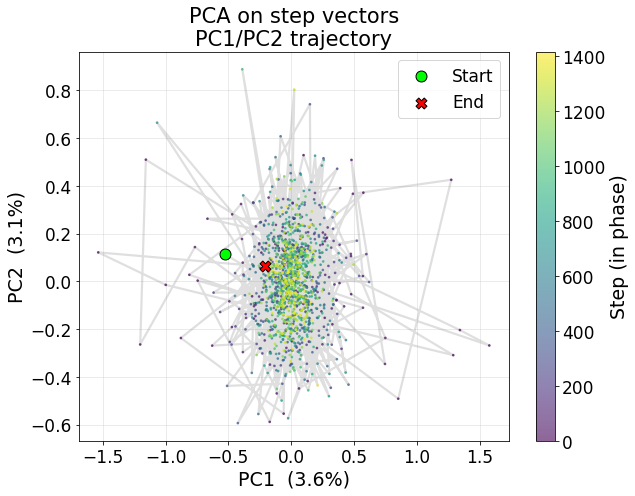

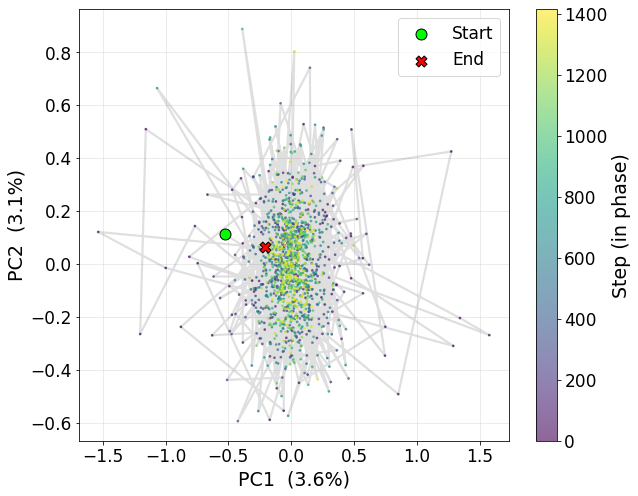

In [21]:
plot_step_vector_pca(show_title=True)
plot_step_vector_pca(show_title=False)

In [ ]:
# ============================================================
#  ZELLE 11 – Screeplot: Cumulative explained variance
# ============================================================


LBL, TTL, TCK = 20, 22, 18   # label / title / tick fontsize

k = np.arange(1, N_COMPONENTS + 1)

# RW-Theorie gilt NUR für Iterates
rw_iter_theory = 6 / (np.pi**2 * k**2)
rw_iter_theory = rw_iter_theory / rw_iter_theory.sum() * exp_iter_phase.sum()


def plot_cumulative_screeplot(show_title=True):
    fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(k, cum_grad, 'b-o', markersize=7, lw=2.4,
            label='Gradients cumulative')
    ax.plot(k, np.cumsum(exp_iter_phase), 'o-', markersize=7, lw=2.9,
            color='darkorange', label='Iterates cumulative')
    ax.plot(k, np.cumsum(rw_iter_theory), 'r--o', markersize=6, lw=2.9,
            label='Random walk theory (iterates only)')
    ax.axhline(90, color='gray', linestyle=':', linewidth=2.5,
               label='90% threshold')

    ax.set_xlabel('Number of principal components', fontsize=LBL)
    ax.set_ylabel('Cumulative explained variance (%)', fontsize=LBL)
    ax.set_xticks(k)
    ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        ax.set_title('Cumulative explained variance - Iterates vs Steps', fontsize=TTL)

    ax.legend(fontsize=TCK - 1)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

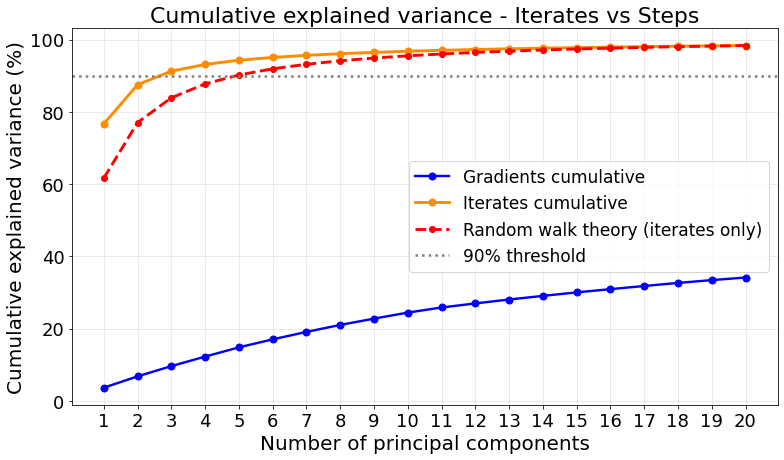

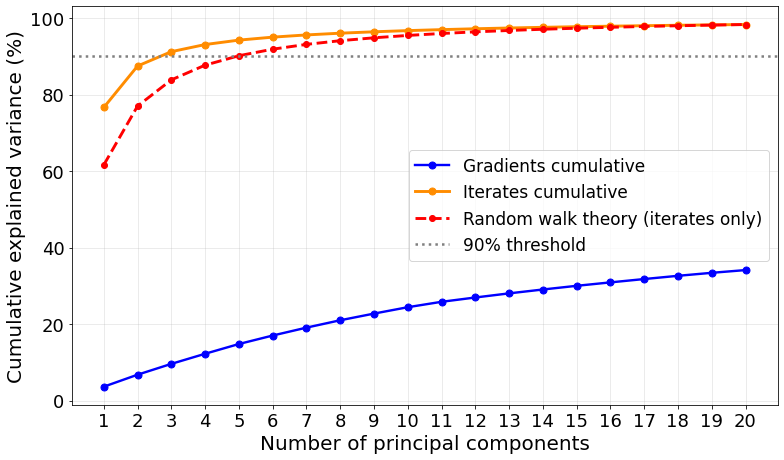

PCs for 90% variance – Gradients: 1  |  Iterates: 3

Note: random walk theory (6/π²k²) only applies to iterates PCA.
There is no analogous analytical prediction for gradient PCA.
Gradients are not cumulative sums – the Antognini formula does not apply.


In [19]:
plot_cumulative_screeplot(show_title=True)
plot_cumulative_screeplot(show_title=False)

d_eff_grad = int(np.argmax(cum_grad >= 90) + 1)
d_eff_iter = int(np.argmax(np.cumsum(exp_iter_phase) >= 90) + 1)
print(f'PCs for 90% variance – Gradients: {d_eff_grad}  |  Iterates: {d_eff_iter}')
print()
print('Note: random walk theory (6/π²k²) only applies to iterates PCA.')
print('There is no analogous analytical prediction for gradient PCA.')
print('Gradients are not cumulative sums – the Antognini formula does not apply.')